## 3. Modeling TF-IDF x LSTM

### 3.1 Importing the Libraries 

In [12]:
import pickle
import os 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input, Concatenate 
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Dense, Embedding, LSTM, # <-- Hanya LSTM, bukan BiLSTM
    Input, Concatenate, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam # <-- Import Adam


In [23]:
MODEL_SAVE_PATH = "../models/lstm_model.keras"

### 3.2 Define the Parameter

In [14]:
VOCAB_SIZE = 5000
TFIDF_FEATURES = 5000
MAX_LEN = 200

### 3.2 Load the Dataset

In [15]:
X_train_pad   = pickle.load(open("../dataset/processed/02_after_FE/X_train_pad.pkl", "rb"))
X_train_tfidf = pickle.load(open("../dataset/processed/02_after_FE/X_train_tfidf.pkl", "rb"))
y_train       = pickle.load(open("../dataset/processed/02_after_FE/y_train.pkl", "rb"))

X_test_pad    = pickle.load(open("../dataset/processed/02_after_FE/X_test_pad.pkl", "rb"))
X_test_tfidf  = pickle.load(open("../dataset/processed/02_after_FE/X_test_tfidf.pkl", "rb"))
y_test        = pickle.load(open("../dataset/processed/02_after_FE/y_test.pkl", "rb"))

### 3.3 Check Array Dimension

In [16]:
print(f"Shape X_train_pad: {X_train_pad.shape}")
print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train_pad: (16479, 200)
Shape X_train_tfidf: (30432, 5000)
Shape y_train: (30432,)
Shape y_test: (4120,)


### 3.4 Build LSTM Model with TF-IDF

In [17]:
# sequence for lstm
input_seq = Input(shape=(MAX_LEN,), name='input_sequence')
x = Embedding(input_dim=VOCAB_SIZE, output_dim=128)(input_seq) 

x = LSTM(32)(x) 

x = Dropout(0.5)(x) 

# vektor TD-IDF
input_tfidf = Input(shape=(TFIDF_FEATURES,), name='input_tfidf') 
y = Dense(16, activation='relu')(input_tfidf) 

# concate
combined = Concatenate()([x, y])

# output layer
z = Dense(32, activation="relu")(combined) 
z = Dropout(0.5)(z) 
output_layer = Dense(1, activation="sigmoid")(z)

# define model
model = Model(inputs=[input_seq, input_tfidf], outputs=output_layer)

optimizer = Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer, 
    metrics=['accuracy']
)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │    640,000 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     20,608 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tfidf         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │     80,016 │ input_tfidf[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,568 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 742,225 (2.83 MB)

 Trainable params: 742,225 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

None


### 3.5 Define Callbacks

In [18]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

### 3.6 Training

In [19]:
history = model.fit(
    [X_train_pad, X_train_tfidf],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8500 - loss: 0.5280 - val_accuracy: 0.9232 - val_loss: 0.2532
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9393 - loss: 0.2185 - val_accuracy: 0.9700 - val_loss: 0.1028
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9735 - loss: 0.1155 - val_accuracy: 0.9815 - val_loss: 0.0669
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9874 - loss: 0.0770 - val_accuracy: 0.9830 - val_loss: 0.0560
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9928 - loss: 0.0569 - val_accuracy: 0.9854 - val_loss: 0.0489
Epoch 6/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9958 - loss: 0.0402 - val_accuracy: 0.9863 - val_loss: 0.0471
Epoch 7/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9966 - loss: 0.0326 - val_accuracy: 0.9870 - val_loss: 0.0460
Epoch 8/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9977 - loss: 0.0250 - val_accu

### 3.7 Evaluation

In [20]:
loss, acc = model.evaluate([X_test_pad, X_test_tfidf], y_test, verbose=1)
print(f"\nAkurasi Test (LSTM + TF-IDF): {acc:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9869 - loss: 0.0488

Akurasi Test (LSTM + TF-IDF): 0.9869


Membuat plot training & validation loss...


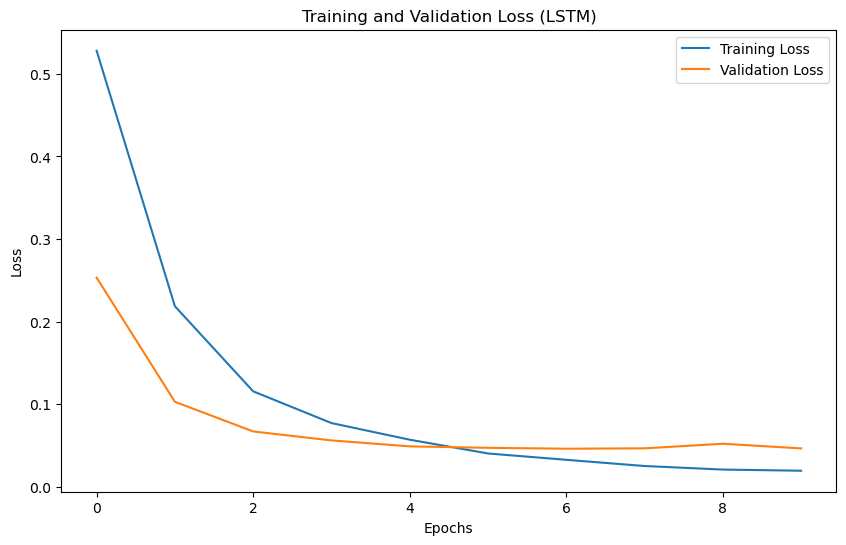

In [21]:
print("Membuat plot training & validation loss...")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 3.8 Save Model

In [24]:
os.makedirs("models", exist_ok=True)
model.save(MODEL_SAVE_PATH)
print("Model LSTM saved to:", MODEL_SAVE_PATH)

Model LSTM saved to: ../models/lstm_model.keras
